# Course: IT549 - Deep Learning
## Lab Assignment 4: Object Detection Evolution — From R-CNN to YOLO

**Name:** Anushka Prajapati 
**ID:**  202301224

## Setup & Installations

In [1]:
# Install required packages
!pip install ultralytics torchvision --quiet
!pip uninstall opencv-python opencv-contrib-python -y
!pip install opencv-contrib-python

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (79.2 MB)


In [2]:
import os
import time
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.ops as ops
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
Device: cuda


In [3]:
import os, random
import xml.etree.ElementTree as ET
import cv2

DATASET_ROOT = "data" 

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train")
TRAIN_LABELS = os.path.join(DATASET_ROOT, "train")

TEST_IMAGES  = os.path.join(DATASET_ROOT, "test")
TEST_LABELS  = os.path.join(DATASET_ROOT, "test")

CLASS_NAMES = ["Apple", "Banana", "Orange"]
CLASS_COLORS = {"Apple": (255, 0, 0), "Banana": (0, 200, 0), "Orange": (0, 100, 255)}

def get_random_image_and_label(images_dir, labels_dir):
    all_images = [f for f in os.listdir(images_dir)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    img_name = random.choice(all_images)
    base_name = os.path.splitext(img_name)[0]

    img_path = os.path.join(images_dir, img_name)
    lbl_path = os.path.join(labels_dir, base_name + ".xml") 

    return img_path, lbl_path

def parse_yolo_labels(label_path, img_w, img_h):
    boxes = []

    tree = ET.parse(label_path)
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name not in CLASS_NAMES:
            continue

        cls_id = CLASS_NAMES.index(class_name)

        bbox = obj.find("bndbox")
        x_min = int(float(bbox.find("xmin").text))
        y_min = int(float(bbox.find("ymin").text))
        x_max = int(float(bbox.find("xmax").text))
        y_max = int(float(bbox.find("ymax").text))

        boxes.append({
            "class_id": cls_id,
            "class_name": class_name,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max
        })

    return boxes

CLASS_NAMES = ["Apple", "Banana", "Orange"]

def convert_xml_to_yolo(xml_path, img_path, save_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img = cv2.imread(img_path)
    if img is None:
        print(f"Skipping (image not found): {img_path}")
        return

    h, w = img.shape[:2]

    lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip().capitalize()

        if class_name not in CLASS_NAMES:
            continue

        cls_id = CLASS_NAMES.index(class_name)

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / w
        y_center = ((ymin + ymax) / 2) / h
        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        lines.append(f"{cls_id} {x_center} {y_center} {bw} {bh}")

    if lines:
        with open(save_path, "w") as f:
            f.write("\n".join(lines))
    else:
        print(f"Empty label (no valid objects): {xml_path}")

def convert_folder(folder):
    for file in os.listdir(folder):
        if file.endswith(".xml"):
            base = file.replace(".xml", "")

            xml_path = os.path.join(folder, file)

            img_path = None
            for ext in [".jpg", ".jpeg", ".png"]:
                temp = os.path.join(folder, base + ext)
                if os.path.exists(temp):
                    img_path = temp
                    break

            if img_path is None:
                print(f"No image found for: {file}")
                continue

            txt_path = os.path.join(folder, base + ".txt")

            convert_xml_to_yolo(xml_path, img_path, txt_path)

    print(f"Converted: {folder}")


convert_folder("data/train")
convert_folder("data/test")

Converted: data/train
Converted: data/test


---
## Preparation: Ground Truth Visualization

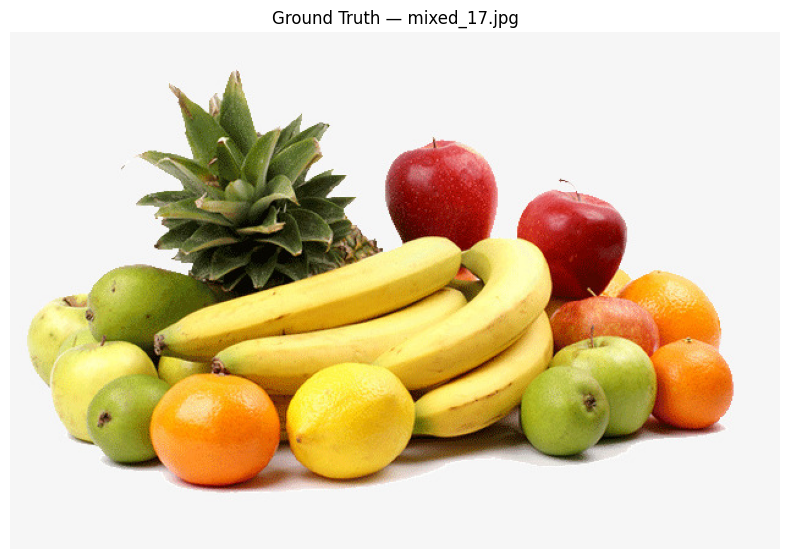

Image: data/train/mixed_17.jpg  |  Size: 630x423  |  Boxes: 0


In [38]:
img_path, lbl_path = get_random_image_and_label(TRAIN_IMAGES, TRAIN_LABELS)

image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
img_h, img_w = image_rgb.shape[:2]

gt_boxes = parse_yolo_labels(lbl_path, img_w, img_h)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.imshow(image_rgb)

for box in gt_boxes:
    x, y = box["x_min"], box["y_min"]
    bw   = box["x_max"] - box["x_min"]
    bh   = box["y_max"] - box["y_min"]
    color = [c / 255 for c in CLASS_COLORS.get(box["class_name"], (200, 200, 200))]
    rect  = patches.Rectangle((x, y), bw, bh, linewidth=2, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x, y - 5, box["class_name"], color=color, fontsize=10, fontweight="bold")

ax.set_title(f"Ground Truth — {os.path.basename(img_path)}", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Image: {img_path}  |  Size: {img_w}x{img_h}  |  Boxes: {len(gt_boxes)}")
for b in gt_boxes:
    print(f"  Class: {b['class_name']}  BBox: [{b['x_min']}, {b['y_min']}, {b['x_max']}, {b['y_max']}]")

---
## Task 1 — Core Concept: Intersection over Union (IoU)

IoU Demonstration

1. Identical Boxes (Complete Overlap)
  Box A : [50, 50, 150, 150]
  Box B : [50, 50, 150, 150]
  IoU   : 1.0000


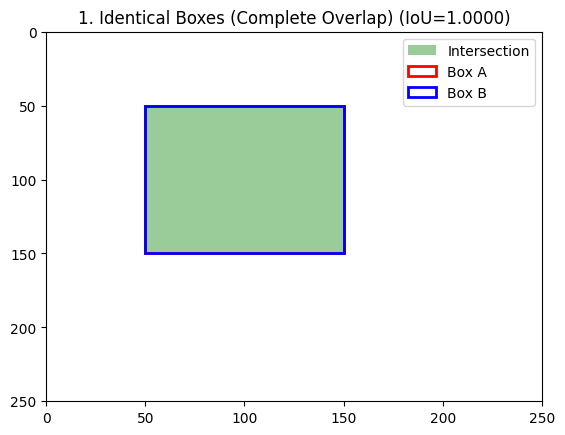


2. Disjoint Boxes (No Overlap)
  Box A : [10, 10, 80, 80]
  Box B : [120, 120, 200, 200]
  IoU   : 0.0000


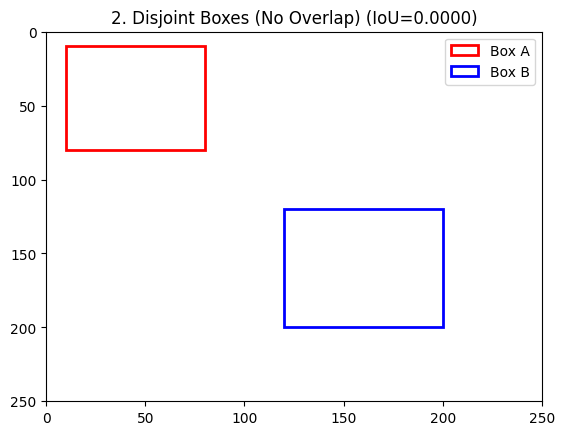


3. Partial Overlap (Standard Case)
  Box A : [50, 50, 150, 150]
  Box B : [100, 100, 200, 200]
  IoU   : 0.1429


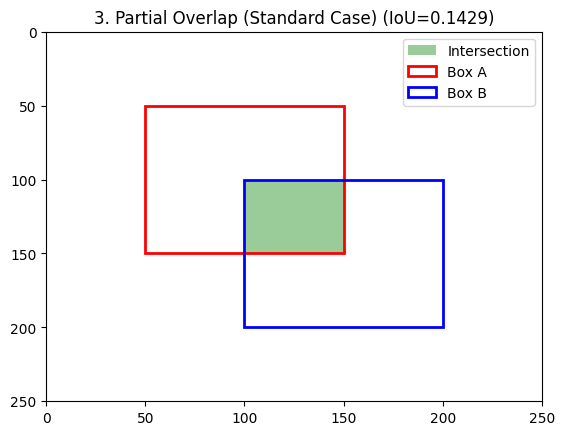


4. Complete Enclosure (One inside another)
  Box A : [30, 30, 220, 220]
  Box B : [100, 100, 150, 150]
  IoU   : 0.0693


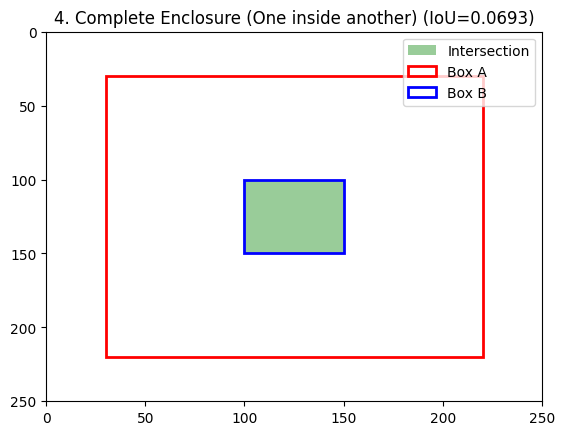

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def compute_iou(box_a, box_b): 
    inter_x1 = max(box_a[0], box_b[0]) 
    inter_y1 = max(box_a[1], box_b[1]) 

    inter_x2 = min(box_a[2], box_b[2]) 
    inter_y2 = min(box_a[3], box_b[3]) 

    inter_w = max(0, inter_x2 - inter_x1) 
    inter_h = max(0, inter_y2 - inter_y1) 

    inter_area = inter_w * inter_h 

    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1]) 
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1]) 

    union_area = area_a + area_b - inter_area 

    if union_area == 0: 
        return 0.0 
    
    return inter_area / union_area

def visualize_iou(box_a, box_b, title=""):
    fig, ax = plt.subplots(1)
    
    rect_a = patches.Rectangle(
        (box_a[0], box_a[1]),
        box_a[2] - box_a[0],
        box_a[3] - box_a[1],
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        label='Box A'
    )
    
    rect_b = patches.Rectangle(
        (box_b[0], box_b[1]),
        box_b[2] - box_b[0],
        box_b[3] - box_b[1],
        linewidth=2,
        edgecolor='blue',
        facecolor='none',
        label='Box B'
    )
    
    inter_x1 = max(box_a[0], box_b[0])
    inter_y1 = max(box_a[1], box_b[1])
    inter_x2 = min(box_a[2], box_b[2])
    inter_y2 = min(box_a[3], box_b[3])

    if inter_x2 > inter_x1 and inter_y2 > inter_y1:
        rect_inter = patches.Rectangle(
            (inter_x1, inter_y1),
            inter_x2 - inter_x1,
            inter_y2 - inter_y1,
            linewidth=0,
            facecolor='green',
            alpha=0.4,
            label='Intersection'
        )
        ax.add_patch(rect_inter)

    ax.add_patch(rect_a)
    ax.add_patch(rect_b)

    ax.set_xlim(0, 250)
    ax.set_ylim(0, 250)
    ax.invert_yaxis() 
    ax.set_title(title)
    ax.legend()

    plt.show()

test_pairs = [
    {
        "label": "1. Identical Boxes (Complete Overlap)",
        "box_a": [50, 50, 150, 150],
        "box_b": [50, 50, 150, 150]
    },
    {
        "label": "2. Disjoint Boxes (No Overlap)",
        "box_a": [10, 10, 80, 80],
        "box_b": [120, 120, 200, 200]
    },
    {
        "label": "3. Partial Overlap (Standard Case)",
        "box_a": [50, 50, 150, 150],
        "box_b": [100, 100, 200, 200]
    },
    {
        "label": "4. Complete Enclosure (One inside another)",
        "box_a": [30, 30, 220, 220],
        "box_b": [100, 100, 150, 150]
    }
]


print("IoU Demonstration")
print("=" * 50)

for pair in test_pairs:
    iou = compute_iou(pair["box_a"], pair["box_b"])

    print(f"\n{pair['label']}")
    print(f"  Box A : {pair['box_a']}")
    print(f"  Box B : {pair['box_b']}")
    print(f"  IoU   : {iou:.4f}")

    visualize_iou(pair["box_a"], pair["box_b"], f"{pair['label']} (IoU={iou:.4f})")

---
## Task 2 — The Baseline: Selective Search (R-CNN Step 1)

Selected image: data/train/mixed_17.jpg
Image size    : (423, 630, 3)
Total proposals generated : 1407
Selective Search time     : 0.643 s


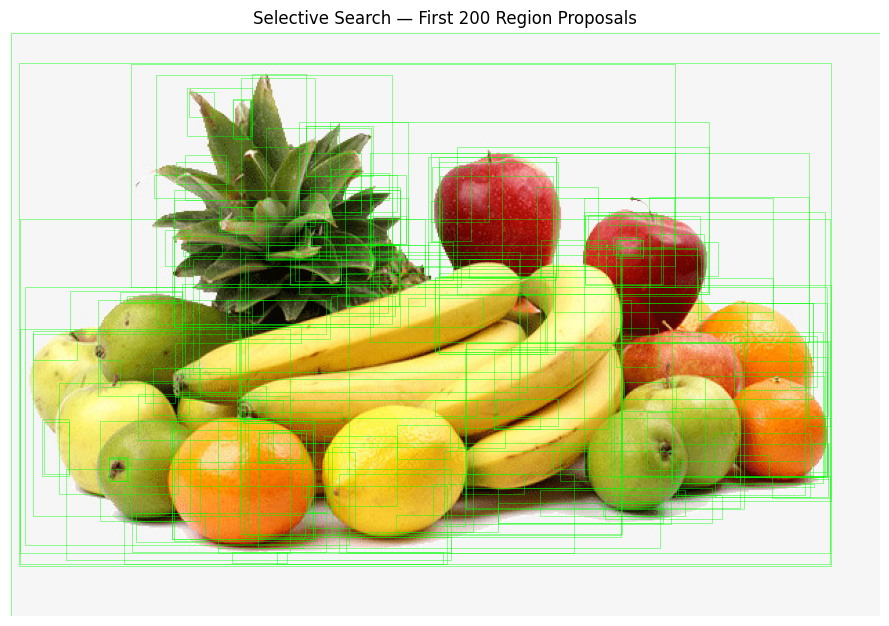

In [40]:
ss_image_rgb   = image_rgb

print(f"Selected image: {img_path}")
print(f"Image size    : {ss_image_rgb.shape}")

ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(image_bgr)
ss.switchToSelectiveSearchFast()

start_ss = time.time()
all_proposals = ss.process()
ss_time = time.time() - start_ss

print(f"Total proposals generated : {len(all_proposals)}")
print(f"Selective Search time     : {ss_time:.3f} s")

proposals_200 = all_proposals[:200]

proposals_xyxy = []
for (x, y, w, h) in proposals_200:
    proposals_xyxy.append([x, y, x + w, y + h])

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.imshow(ss_image_rgb)
for (x1, y1, x2, y2) in proposals_xyxy:
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                               linewidth=0.6, edgecolor="lime", facecolor="none", alpha=0.5)
    ax.add_patch(rect)
ax.set_title("Selective Search — First 200 Region Proposals", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Task 3 — The R-CNN Bottleneck: Sequential Crop + CNN

In [41]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet18_features = torch.nn.Sequential(*list(resnet18.children())[:-1])
resnet18_features = resnet18_features.to(DEVICE).eval()

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

top_100 = proposals_xyxy[:100]

print("Running R-CNN style: 100 sequential crop → resize → CNN forward passes...")
rcnn_features = []

start_rcnn = time.time()
with torch.no_grad():
    for (x1, y1, x2, y2) in top_100:
        
        h, w = ss_image_rgb.shape[:2]
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(w, x2), min(h, y2)

        crop = ss_image_rgb[y1c:y2c, x1c:x2c]
        if crop.size == 0:
            continue

        tensor = preprocess(crop).unsqueeze(0).to(DEVICE)
        feat   = resnet18_features(tensor)
        rcnn_features.append(feat.squeeze().cpu())

rcnn_time = time.time() - start_rcnn

print(f"\nTask 3 — R-CNN (100 crops)")
print(f"  Crops processed    : {len(rcnn_features)}")
print(f"  Feature vector dim : {rcnn_features[0].shape}")
print(f"  Total time         : {rcnn_time:.4f} s  ({rcnn_time * 1000:.2f} ms)")

Running R-CNN style: 100 sequential crop → resize → CNN forward passes...

Task 3 — R-CNN (100 crops)
  Crops processed    : 100
  Feature vector dim : torch.Size([512])
  Total time         : 0.3415 s  (341.54 ms)


---
## Task 4 — Fast R-CNN: Single Forward Pass + RoI Pooling

In [42]:
conv_body = torch.nn.Sequential(*list(resnet18.children())[:-2])
conv_body = conv_body.to(DEVICE).eval()

full_img_tensor = preprocess(ss_image_rgb).unsqueeze(0).to(DEVICE)

start_fast = time.time()

with torch.no_grad():
    feature_map = conv_body(full_img_tensor)
    
    feat_h, feat_w = feature_map.shape[2], feature_map.shape[3]
    inp_h,  inp_w  = full_img_tensor.shape[2], full_img_tensor.shape[3]
    spatial_scale  = feat_h / inp_h 
    
    print(f"Feature map size : {feature_map.shape}")
    print(f"Spatial scale    : {spatial_scale:.5f}  (= 1/{int(1/spatial_scale)})")

    orig_h, orig_w = ss_image_rgb.shape[:2]
    scale_x = inp_w / orig_w
    scale_y = inp_h / orig_h

    rois = []
    for (x1, y1, x2, y2) in top_100:
        rois.append([0, x1 * scale_x, y1 * scale_y, x2 * scale_x, y2 * scale_y])

    rois_tensor = torch.tensor(rois, dtype=torch.float32).to(DEVICE)
    
    pooled = ops.roi_pool(
        input        = feature_map,
        boxes        = rois_tensor,
        output_size  = (feat_h, feat_w),
        spatial_scale= spatial_scale
    ) 
    
fast_rcnn_time = time.time() - start_fast

print(f"\nRoI-pooled output shape : {pooled.shape}")
print(f"\nTask 4 — Fast R-CNN (1 CNN pass + 1 RoI pool)")
print(f"  Total time : {fast_rcnn_time:.4f} s  ({fast_rcnn_time * 1000:.2f} ms)")
print(f"\n{'='*50}")
print(f"Speed Comparison")
print(f"  R-CNN  (Task 3) : {rcnn_time * 1000:.2f} ms")
print(f"  Fast R-CNN (T4) : {fast_rcnn_time * 1000:.2f} ms")
print(f"  Speedup         : {rcnn_time / fast_rcnn_time:.1f}x faster")

Feature map size : torch.Size([1, 512, 7, 7])
Spatial scale    : 0.03125  (= 1/32)

RoI-pooled output shape : torch.Size([100, 512, 7, 7])

Task 4 — Fast R-CNN (1 CNN pass + 1 RoI pool)
  Total time : 0.0085 s  (8.51 ms)

Speed Comparison
  R-CNN  (Task 3) : 341.54 ms
  Fast R-CNN (T4) : 8.51 ms
  Speedup         : 40.1x faster


### Conceptual Analysis — Task 4

**Q: What redundant mathematical operations does Fast R-CNN eliminate to achieve this efficiency?**

In standard R-CNN, each of the *N* region proposals is cropped from the raw image, resized to a fixed size (e.g. 224×224), and then independently forwarded through the entire convolutional backbone. This means the same pixel regions are processed by many conv layers *N* times — all those floating-point multiplications and additions are fully redundant for overlapping proposals.

Fast R-CNN eliminates this redundancy by running the backbone CNN **exactly once** on the full image to produce a shared feature map. The expensive convolutional computations (hundreds of millions of multiply-accumulate operations per forward pass) are therefore performed only once regardless of the number of proposals. After that single pass, RoI Pooling extracts a fixed-size feature descriptor for each proposal directly from the shared feature map using simple max-pooling — a far cheaper operation. The speedup scales roughly linearly with *N*: processing 100 proposals is approximately 100× cheaper than running 100 independent CNN passes.

---
## Task 5 — Faster R-CNN Inference

Raw predictions: 50 boxes
After confidence filtering: 12 boxes
After class filtering (Apple/Banana/Orange): 12 boxes


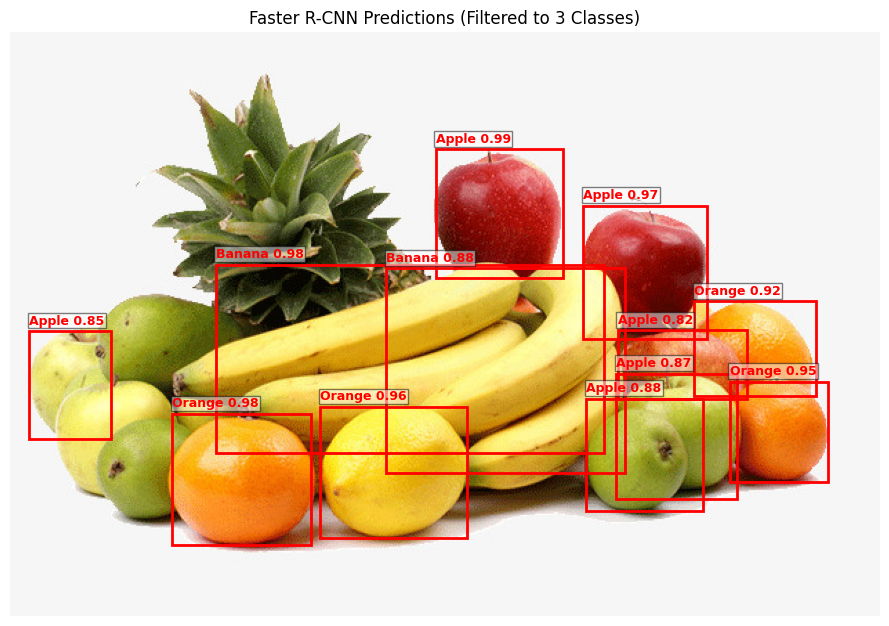

In [43]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

faster_rcnn = fasterrcnn_resnet50_fpn(
    weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
faster_rcnn = faster_rcnn.to(DEVICE).eval()

COCO_TO_FRUIT = {
    52: "Banana",
    53: "Apple",
    55: "Orange"
}

to_tensor = transforms.ToTensor()
test_tensor = to_tensor(ss_image_rgb).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    predictions = faster_rcnn(test_tensor)

pred = predictions[0]
print(f"Raw predictions: {len(pred['boxes'])} boxes")

CONFIDENCE_THRESHOLD = 0.80

def filter_predictions(pred, threshold=0.80):
    keep = pred["scores"] >= threshold
    boxes = pred["boxes"][keep].cpu().numpy()
    labels = pred["labels"][keep].cpu().numpy()
    scores = pred["scores"][keep].cpu().numpy()
    return boxes, labels, scores

f_boxes, f_labels, f_scores = filter_predictions(pred, CONFIDENCE_THRESHOLD)
print(f"After confidence filtering: {len(f_boxes)} boxes")

filtered_boxes = []
filtered_labels = []
filtered_scores = []

for box, lbl, score in zip(f_boxes, f_labels, f_scores):
    if lbl in COCO_TO_FRUIT:
        filtered_boxes.append(box)
        filtered_labels.append(COCO_TO_FRUIT[lbl])
        filtered_scores.append(score)

print(f"After class filtering (Apple/Banana/Orange): {len(filtered_boxes)} boxes")

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.imshow(ss_image_rgb)

for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    x1, y1, x2, y2 = box

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

    ax.text(
        x1,
        y1 - 5,
        f"{label} {score:.2f}",
        color="red",
        fontsize=9,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.5, pad=1)
    )

ax.set_title("Faster R-CNN Predictions (Filtered to 3 Classes)", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.show()

### Conceptual Analysis — Task 5

**Q: How does the RPN eliminate the need for external algorithms like Selective Search?**

Selective Search is a CPU-based, hand-crafted algorithm that groups pixels by colour, texture, and size through a hierarchical merging process entirely separate from the detection network. This makes it slow and unable to benefit from GPU acceleration or end-to-end training.

The **Region Proposal Network (RPN)** replaces it by reusing the very same convolutional feature map that the detection head will later use. A small 3×3 sliding window is applied across this shared feature map. At every spatial location the RPN predicts, for each of *k* pre-defined anchor boxes (varying scales and aspect ratios), (1) an objectness score (object vs. background) and (2) four bounding-box regression offsets. This produces thousands of candidate boxes in a single GPU-native forward pass.

Because the RPN shares weights with the backbone and is trained jointly with the detector via backpropagation, it learns task-specific features — not hand-crafted cues. The result is proposals that are faster to generate (GPU parallel), more accurate for the detection task, and fully integrated into the end-to-end training pipeline.

---
## Task 6 — Non-Maximum Suppression (NMS)

NMS Demonstration
Input : 6 boxes
Output: 3 boxes after NMS
  Box [100, 100, 300, 300]  score=0.95
  Box [200, 200, 400, 400]  score=0.91
  Box [10, 10, 60, 60]  score=0.60

Faster R-CNN predictions (score ≥ 0.3): 24 boxes
After class-wise NMS               : 24 boxes


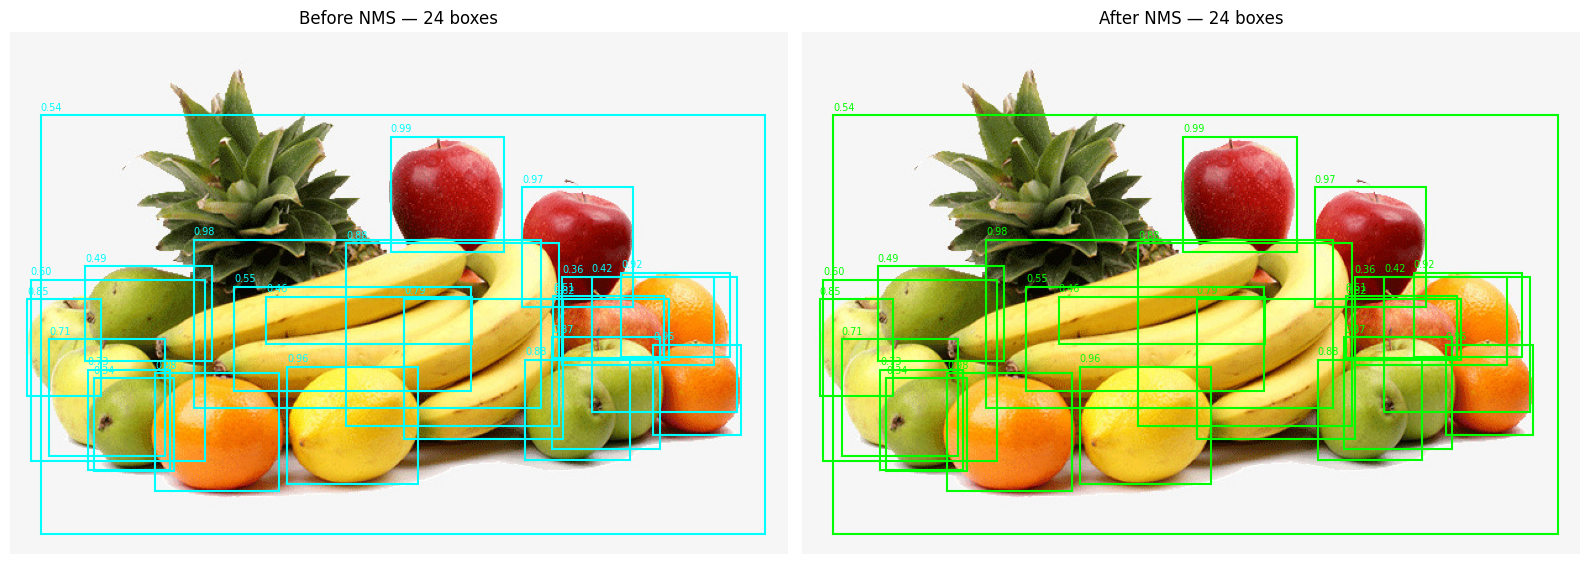

In [44]:
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def non_maximum_suppression(boxes, scores, iou_threshold=0.5):

    if len(boxes) == 0:
        return [], [], []

    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept_indices = []

    while order:
        best_idx = order[0]
        kept_indices.append(best_idx)
        order = order[1:]

        remaining = []
        for idx in order:
            iou = compute_iou(boxes[best_idx], boxes[idx])
            if iou <= iou_threshold:
                remaining.append(idx)
        order = remaining

    kept_boxes  = [boxes[i]  for i in kept_indices]
    kept_scores = [scores[i] for i in kept_indices]

    return kept_boxes, kept_scores, kept_indices


demo_boxes = [
    [100, 100, 300, 300],
    [110, 105, 305, 295],
    [115, 108, 310, 302],
    [200, 200, 400, 400],
    [205, 202, 398, 398],
    [10,  10,  60,  60],
]
demo_scores = [0.95, 0.88, 0.72, 0.91, 0.75, 0.60]

print("NMS Demonstration")
print(f"Input : {len(demo_boxes)} boxes")

nms_boxes, nms_scores, _ = non_maximum_suppression(
    demo_boxes, demo_scores, iou_threshold=0.5
)

print(f"Output: {len(nms_boxes)} boxes after NMS")
for b, s in zip(nms_boxes, nms_scores):
    print(f"  Box {b}  score={s:.2f}")


raw_boxes  = pred["boxes"].cpu().numpy().tolist()
raw_scores = pred["scores"].cpu().numpy().tolist()
raw_labels = pred["labels"].cpu().numpy().tolist()

filtered = [(b, s, l) for b, s, l in zip(raw_boxes, raw_scores, raw_labels) if s >= 0.3]

if filtered:
    fb, fs, fl = zip(*filtered)

    print(f"\nFaster R-CNN predictions (score ≥ 0.3): {len(fb)} boxes")

    classwise_data = defaultdict(list)

    for b, s, l in zip(fb, fs, fl):
        classwise_data[l].append((b, s))

    final_boxes = []
    final_scores = []
    final_labels = []

    for cls, items in classwise_data.items():
        boxes_cls = [item[0] for item in items]
        scores_cls = [item[1] for item in items]

        nms_b, nms_s, nms_i = non_maximum_suppression(
            boxes_cls, scores_cls, iou_threshold=0.5
        )

        final_boxes.extend(nms_b)
        final_scores.extend(nms_s)
        final_labels.extend([cls] * len(nms_b))

    print(f"After class-wise NMS               : {len(final_boxes)} boxes")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(ss_image_rgb)
    for box, score in zip(fb, fs):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor="cyan", facecolor="none"
        )
        axes[0].add_patch(rect)
        axes[0].text(x1, y1-4, f"{score:.2f}", color="cyan", fontsize=7)

    axes[0].set_title(f"Before NMS — {len(fb)} boxes")
    axes[0].axis("off")

    axes[1].imshow(ss_image_rgb)
    for box, score in zip(final_boxes, final_scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor="lime", facecolor="none"
        )
        axes[1].add_patch(rect)
        axes[1].text(x1, y1-4, f"{score:.2f}", color="lime", fontsize=7)

    axes[1].set_title(f"After NMS — {len(final_boxes)} boxes")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

### Conceptual Analysis — Task 6

**Q: How does a high vs. low IoU threshold affect detection of tightly packed objects?**

The IoU threshold in NMS controls how much overlap is tolerated before a lower-scoring box is suppressed.


**Very high (0.9)** Only boxes that nearly perfectly overlap with the selected box are suppressed. Because the predicted boxes around individual apples in a basket overlap only moderately with each other (they are nearby but not the same object), almost none are suppressed. The result preserves many distinct detections — good for dense scenes — but also keeps many duplicate boxes for *the same* apple, producing noisy outputs.

**Very low (0.1)** Any box with even a tiny spatial overlap (10 %) relative to the selected box is immediately suppressed. In a dense fruit basket, the bounding boxes for neighbouring apples legitimately overlap a little due to proximity. A threshold of 0.1 would suppress these *true* neighbouring detections, merging many apples into a single surviving box. The result severely under-counts objects and misses most instances in the cluster.

**Practical guidance:** For tightly packed objects, a *moderate-to-high* threshold (0.4–0.6) is preferred. It suppresses duplicate boxes for the same object while retaining separate boxes for genuinely adjacent objects.

---
## Task 7 — YOLO Fine-Tuning

In [45]:
import yaml

yaml_content = {
    "train": "data/train", 
    "val": "data/test",    
    "nc": 3,
    "names": ["Apple", "Banana", "Orange"]
}

# This creates the dataset.yaml file
with open("dataset.yaml", "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print("dataset.yaml created successfully!")

dataset.yaml created successfully!


In [46]:
from ultralytics import YOLO
import torch

model = YOLO("yolov8n.pt")

results = model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project=".", 
    device=0 if torch.cuda.is_available() else "cpu"
)

Ultralytics 8.4.33 🚀 Python-3.13.7 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 15839MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [47]:
from ultralytics import YOLO

metrics = model.val(data="dataset.yaml") 

map50 = metrics.box.map50
map5095 = metrics.box.map

print(f"\nTest Set Evaluation — Fine-tuned YOLOv8n")
print(f"  mAP@50    : {map50:.4f}")
print(f"  mAP@50-95 : {map5095:.4f}")

Ultralytics 8.4.33 🚀 Python-3.13.7 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 15839MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1644.0±974.3 MB/s, size: 42.7 KB)
val: Scanning /home/heer/Public/Deep_Learning_2026/Lab4/data/test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 36.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 8.1it/s 0.5s0.2s
                   all         60        117      0.867      0.805      0.916      0.669
                 Apple         24         35       0.86       0.88      0.935      0.781
                Banana         22         40       0.83        0.8      0.869      0.546
                Orange         22         42      0.911      0.734      0.945       0.68
Speed: 1.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /hom


0: 640x640 1 Orange, 7.4ms
1: 640x640 1 Banana, 7.4ms
Speed: 1.2ms preprocess, 7.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


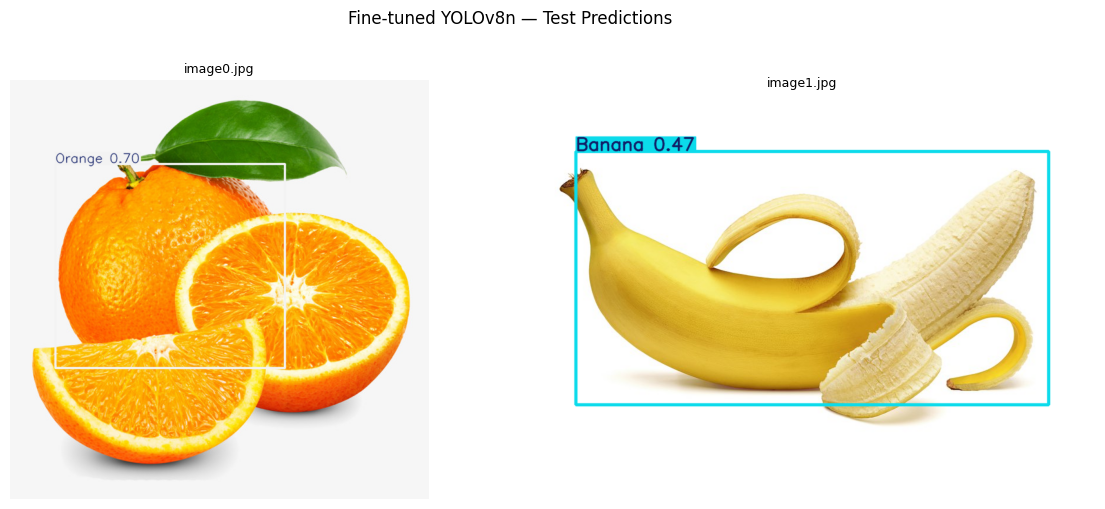

In [48]:
test_image_paths = [
    os.path.join(TEST_IMAGES, f)
    for f in random.sample(os.listdir(TEST_IMAGES), min(3, len(os.listdir(TEST_IMAGES))))
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

preds = model.predict(source=test_image_paths, conf=0.25, iou=0.5)

fig, axes = plt.subplots(1, len(preds), figsize=(6 * len(preds), 5))
if len(preds) == 1:
    axes = [axes]

for ax, pred_result in zip(axes, preds):
    plotted = pred_result.plot()
    ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(pred_result.path), fontsize=9)
    ax.axis("off")

plt.suptitle("Fine-tuned YOLOv8n — Test Predictions", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Comparison Table: Faster R-CNN vs YOLO (pre-trained) vs YOLO (fine-tuned)

In [ ]:
!pip install torchmetrics

In [81]:
!pip install faster-coco-eval

In [49]:
import os
import time
import torch
import cv2
from ultralytics import YOLO
from torchvision.transforms.functional import to_tensor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

NUM_RUNS = 5  

print("Running Inference Speed Tests...")
sample_img, _ = get_random_image_and_label(TEST_IMAGES, TEST_LABELS)
sample_rgb    = cv2.cvtColor(cv2.imread(sample_img), cv2.COLOR_BGR2RGB)
sample_tensor = to_tensor(sample_rgb).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    _ = faster_rcnn(sample_tensor)
t_start = time.time()
with torch.no_grad():
    for _ in range(NUM_RUNS):
        _ = faster_rcnn(sample_tensor)
frcnn_ms = (time.time() - t_start) / NUM_RUNS * 1000

pretrained_yolo = YOLO("yolov8n.pt")
pretrained_yolo.predict(source=sample_img, verbose=False)
t_start = time.time()
for _ in range(NUM_RUNS):
    pretrained_yolo.predict(source=sample_img, verbose=False)
pretrained_yolo_ms = (time.time() - t_start) / NUM_RUNS * 1000

model.predict(source=sample_img, verbose=False)
t_start = time.time()
for _ in range(NUM_RUNS):
    model.predict(source=sample_img, verbose=False)
finetuned_yolo_ms = (time.time() - t_start) / NUM_RUNS * 1000

print("Running Zero-Shot Baseline Evaluations...")

frcnn_metric = MeanAveragePrecision(box_format='xyxy')
yolo_pt_metric = MeanAveragePrecision(box_format='xyxy')

frcnn_map = {53: 0, 52: 1, 55: 2}   
yolo_map = {47: 0, 46: 1, 49: 2}

frcnn_preds, yolo_pt_preds, all_targets = [], [], []

for img_name in os.listdir(TEST_IMAGES):
    if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        continue
        
    img_path = os.path.join(TEST_IMAGES, img_name)
    base_name = os.path.splitext(img_name)[0]
    txt_path = os.path.join(TEST_LABELS, base_name + ".txt")
    
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = to_tensor(img_rgb).unsqueeze(0).to(DEVICE)
    
    gt_boxes, gt_labels = [], []
    if os.path.exists(txt_path):
        with open(txt_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:])
                    xmin, ymin = (cx - bw / 2) * w, (cy - bh / 2) * h
                    xmax, ymax = (cx + bw / 2) * w, (cy + bh / 2) * h
                    gt_boxes.append([xmin, ymin, xmax, ymax])
                    gt_labels.append(cls_id)
                    
    target = dict(
        boxes=torch.tensor(gt_boxes, dtype=torch.float32).to(DEVICE) if gt_boxes else torch.empty((0, 4)).to(DEVICE),
        labels=torch.tensor(gt_labels, dtype=torch.int64).to(DEVICE)
    )
    all_targets.append(target)
    
    with torch.no_grad():
        f_pred = faster_rcnn(img_tensor)[0]
    f_boxes, f_scores, f_labels = [], [], []
    for box, score, label in zip(f_pred['boxes'], f_pred['scores'], f_pred['labels']):
        lbl_idx = int(label.item())
        if lbl_idx in frcnn_map:
            f_boxes.append(box.tolist())
            f_scores.append(score.item())
            f_labels.append(frcnn_map[lbl_idx])
            
    frcnn_preds.append(dict(
        boxes=torch.tensor(f_boxes, dtype=torch.float32).to(DEVICE) if f_boxes else torch.empty((0, 4)).to(DEVICE),
        scores=torch.tensor(f_scores, dtype=torch.float32).to(DEVICE),
        labels=torch.tensor(f_labels, dtype=torch.int64).to(DEVICE)
    ))

    y_res = pretrained_yolo.predict(img_path, verbose=False)[0]
    y_boxes, y_scores, y_labels = [], [], []
    if len(y_res.boxes) > 0:
        for box, score, label in zip(y_res.boxes.xyxy, y_res.boxes.conf, y_res.boxes.cls):
            lbl_idx = int(label.item())
            if lbl_idx in yolo_map:
                y_boxes.append(box.tolist())
                y_scores.append(score.item())
                y_labels.append(yolo_map[lbl_idx])
                
    yolo_pt_preds.append(dict(
        boxes=torch.tensor(y_boxes, dtype=torch.float32).to(DEVICE) if y_boxes else torch.empty((0, 4)).to(DEVICE),
        scores=torch.tensor(y_scores, dtype=torch.float32).to(DEVICE),
        labels=torch.tensor(y_labels, dtype=torch.int64).to(DEVICE)
    ))

frcnn_metric.update(frcnn_preds, all_targets)
frcnn_results = frcnn_metric.compute()

yolo_pt_metric.update(yolo_pt_preds, all_targets)
yolo_pt_results = yolo_pt_metric.compute()

print("Running Fine-Tuned Model Validation...")
ft_metrics = model.val(data="dataset.yaml", verbose=False) 

header = f"{'Model':<30} {'Inference (ms)':>16} {'Precision':>10} {'Recall':>8} {'mAP@50':>8} {'mAP@50-95':>10}"
sep    = "-" * len(header)

print("\n" + sep)
print(header)
print(sep)
print(f"{'Faster R-CNN (pretrained)':<30} {frcnn_ms:>16.1f} {'N/A*':>10} {'N/A*':>8} "
      f"{frcnn_results['map_50'].item():>8.4f} {frcnn_results['map'].item():>10.4f}")
print(f"{'YOLOv8n (pretrained)':<30} {pretrained_yolo_ms:>16.1f} {'N/A*':>10} {'N/A*':>8} "
      f"{yolo_pt_results['map_50'].item():>8.4f} {yolo_pt_results['map'].item():>10.4f}")
print(f"{'YOLOv8n (fine-tuned)':<30} {finetuned_yolo_ms:>16.1f} "
      f"{ft_metrics.box.mp:>10.4f} {ft_metrics.box.mr:>8.4f} "
      f"{ft_metrics.box.map50:>8.4f} {ft_metrics.box.map:>10.4f}")
print(sep)
print("* Precision and Recall are isolated natively for the fine-tuned model via Ultralytics.")
print("  Zero-Shot mAP scores are calculated via Torchmetrics mapping.")

Running Inference Speed Tests...
Running Zero-Shot Baseline Evaluations...
Running Fine-Tuned Model Validation...
Ultralytics 8.4.33 🚀 Python-3.13.7 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5080, 15839MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5801.7±3267.5 MB/s, size: 73.3 KB)
val: Scanning /home/heer/Public/Deep_Learning_2026/Lab4/data/test.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 36.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 8.6it/s 0.5s0.2s
                   all         60        117      0.867      0.805      0.916      0.669
Speed: 1.3ms preprocess, 1.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /home/heer/Public/Deep_Learning_2026/runs/detect/val4

---------------------------------------------------------------------------------------
Model                            Inference (ms)  Precision   Recall   mAP@50  mAP@50-95
-----

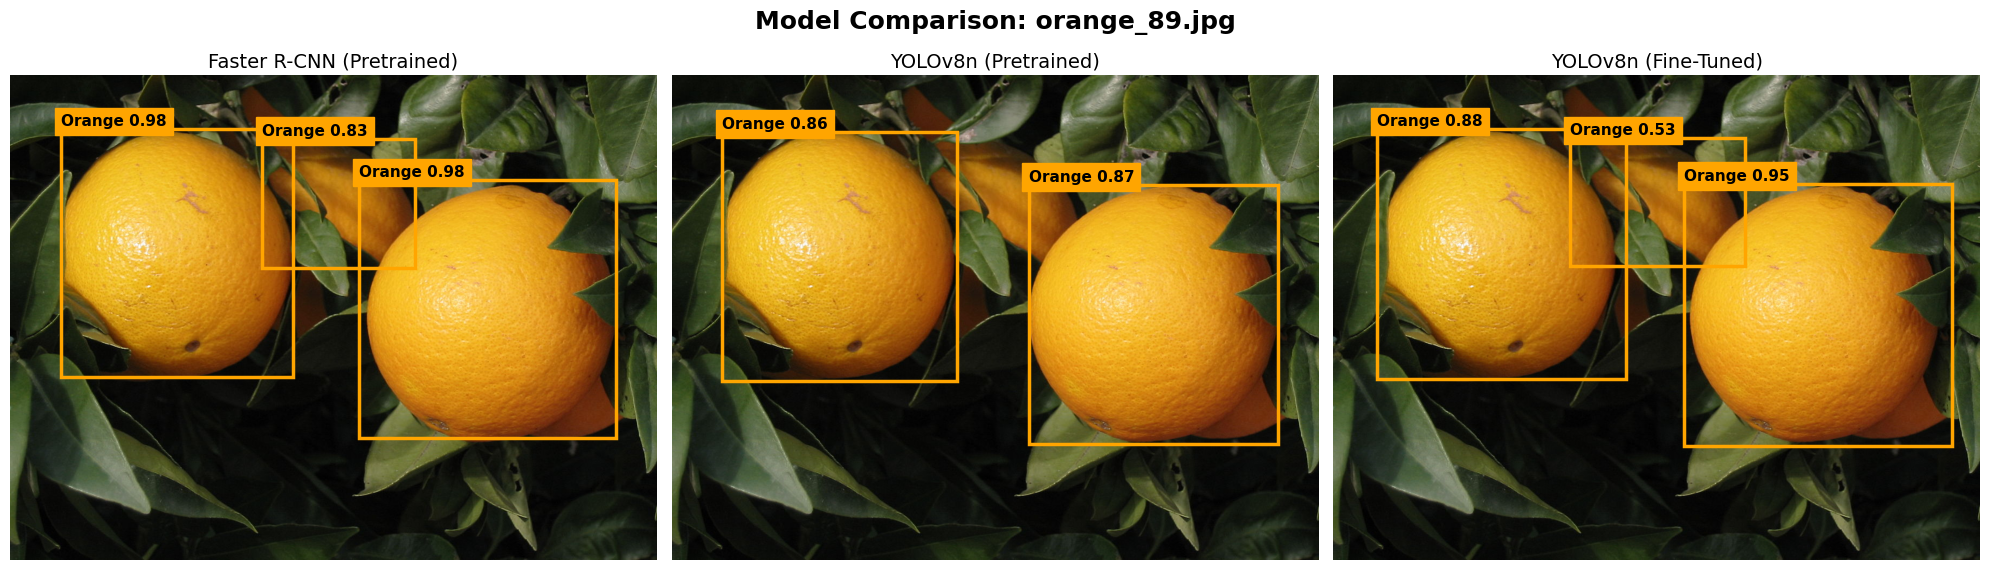

In [73]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import cv2

img_path, _ = get_random_image_and_label(TEST_IMAGES, TEST_LABELS)
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_tensor = to_tensor(img_rgb).unsqueeze(0).to(DEVICE)

frcnn_map = {53: 0, 52: 1, 55: 2}
yolo_map = {47: 0, 46: 1, 49: 2}

class_names = {0: "Apple", 1: "Banana", 2: "Orange"}
class_colors = {0: "red", 1: "yellow", 2: "orange"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Model Comparison: {os.path.basename(img_path)}", fontsize=18, fontweight="bold")

def draw_boxes(ax, boxes, scores, labels, title):
    """Helper function to draw bounding boxes on a specific subplot"""
    ax.imshow(img_rgb)
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    
    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        color = class_colors.get(label, "cyan")
        name = class_names.get(label, "Unknown")
        
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2.5, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        
        ax.text(x1, y1-6, f"{name} {score:.2f}", color="black", backgroundcolor=color, 
                fontsize=11, fontweight="bold")

with torch.no_grad():
    f_pred = faster_rcnn(img_tensor)[0]
f_boxes, f_scores, f_labels = [], [], []

for box, score, label in zip(f_pred['boxes'], f_pred['scores'], f_pred['labels']):
    if score > 0.5:
        lbl_idx = int(label.item())
        if lbl_idx in frcnn_map:
            f_boxes.append(box.tolist())
            f_scores.append(score.item())
            f_labels.append(frcnn_map[lbl_idx])

draw_boxes(axes[0], f_boxes, f_scores, f_labels, "Faster R-CNN (Pretrained)")


y_pt_res = pretrained_yolo.predict(img_path, verbose=False, conf=0.5)[0]
y_pt_boxes, y_pt_scores, y_pt_labels = [], [], []

if len(y_pt_res.boxes) > 0:
    for box, score, label in zip(y_pt_res.boxes.xyxy, y_pt_res.boxes.conf, y_pt_res.boxes.cls):
        lbl_idx = int(label.item())
        if lbl_idx in yolo_map:
            y_pt_boxes.append(box.tolist())
            y_pt_scores.append(score.item())
            y_pt_labels.append(yolo_map[lbl_idx])

draw_boxes(axes[1], y_pt_boxes, y_pt_scores, y_pt_labels, "YOLOv8n (Pretrained)")


y_ft_res = model.predict(img_path, verbose=False, conf=0.5)[0]
y_ft_boxes, y_ft_scores, y_ft_labels = [], [], []

if len(y_ft_res.boxes) > 0:
    for box, score, label in zip(y_ft_res.boxes.xyxy, y_ft_res.boxes.conf, y_ft_res.boxes.cls):
        y_ft_boxes.append(box.tolist())
        y_ft_scores.append(score.item())
        y_ft_labels.append(int(label.item()))

draw_boxes(axes[2], y_ft_boxes, y_ft_scores, y_ft_labels, "YOLOv8n (Fine-Tuned)")

plt.tight_layout()
plt.show()